<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/01_clustering_exercises/exercise_kmeans_gmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: Kmeans and GMM

## Learning objectives

- apply K-means clustering
- apply Gaussian Mixture Models
- estimate the optimal number of clusters using:
  - the elbow method
  - the silhouette score
  - the Akaike Information Criterion (AIC) and the Bayesian Information Criterion (AIC)

## 1. Imports and setup

Run the next cell to import the libraries and initiliaze the random number generator.


In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)

## 2. Generate a synthetic dataset

Run the next cell to create a synthetic dataset with features that could resemble biomedical measurements.

In [254]:
X, y_true = make_blobs(
    n_samples=450,
    centers=4,
    n_features=4,
    cluster_std=[1.1, 1.5, 1.0, 1.3],
    random_state=42
)

feature_names = [
    "inflammatory_marker",
    "hrv_index",
    "glucose_marker",
    "oxygenation_feature"
]

df = pd.DataFrame(X, columns=feature_names)
df["true_group"] = y_true
df.head()

,inflammatory_marker,hrv_index,glucose_marker,oxygenation_feature,true_group
0,-8.343437,-5.299647,-10.262426,11.272096,1
1,-2.401754,8.163975,4.666840,2.520968,0
2,0.741996,5.033909,-8.938109,9.299021,2
3,9.266256,-5.575722,-6.838419,-6.091825,3
4,-4.263068,8.354974,4.645647,2.024848,0


## 2bis. A more complicated dataset

After you finished the exercise with the first dataset, create this alternative dataset and repeat everything.

Note the following differences:
* Does the Elbow method works as well as before ?
* What about the silhoutte score ?
* Is the clustering of K-means as good as before ? Why ?
* Is GMM clustering better ? Why ?

In [255]:
# Cluster 1
mean1 = [1, 6]
cov1 = [[0.5, 0.0],
        [0.0, 0.5]]
X1 = np.random.multivariate_normal(mean1, cov1, 120)

# Cluster 2
mean2 = [9, 7]
cov2 = [[2.5, 1.8],
        [1.8, 1.5]]
X2 = np.random.multivariate_normal(mean2, cov2, 180)

# Cluster 3
mean3 = [-4, 4]
cov3 = [[4.2, -2.4],
        [-2.4, 4.0]]
X3 = np.random.multivariate_normal(mean3, cov3, 100)

X = np.vstack([X1, X2, X3])
y_true = np.array([0]*len(X1) + [1]*len(X2) + [2]*len(X3))

## 3. Explore and standardize the data

Clustering methods are sensitive to the scale of the variables.
For this reason, it is common to standardize the features before fitting the models.
Standardize each feature to have average equal to zero and standard deviation equal to one.


In [256]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [257]:
np.mean(X_scaled, axis=0)

array([-3.09752224e-16, -1.36002321e-16])

In [258]:
np.std(X_scaled, axis=0)

array([1., 1.])

### Quick visualization in 2D

Make a scatter plot of the samples in 2D using the first two features. This is intended only for a visualization of the dataset. Clustering will be performed considering all the features.


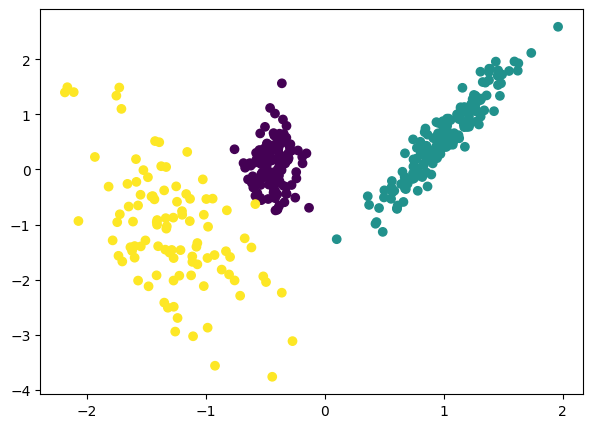

In [259]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true)

## 4. K-means clustering

Run K-Means clustering with an arbitrary value for k.
* Use the KMeans class of scikitlearn. Check the parameters: n_clusters, random_state, n_init
* Use the method fit_predict to calculate the clusters
* Make a scatter plot in 2D with points coloured using the cluster index

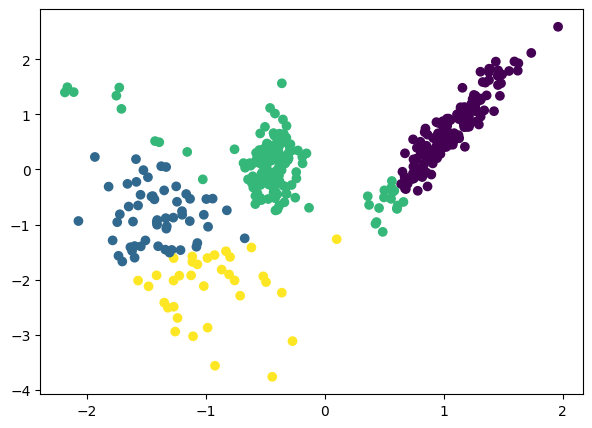

In [260]:
k = 4
km = KMeans(n_clusters=k, random_state=42)
y_c = km.fit_predict(X_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_c)

## 5. Choosing the number of clusters for K-means: elbow method

The elbow method evaluates the inertia (within-cluster sum of squares) for different values of `k`. The optimal number of cluster is the one where the decrease in inertia starts to slow down.
* Compute the inertia for different value of k (see the inertia_ value of the KMeans class)
* Make a plot of the inertia as a function of k
* Select the optimal number of clusters

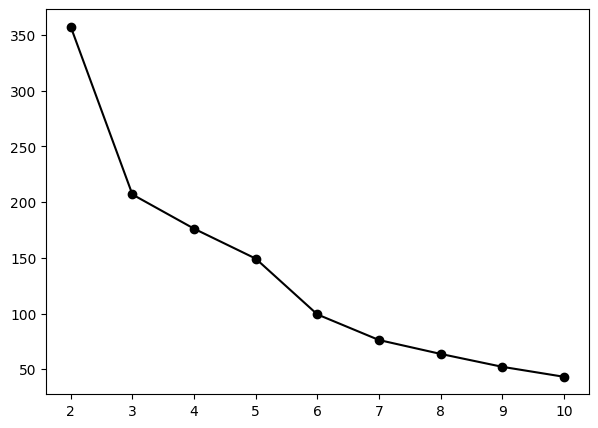

In [261]:
Ks = range(2,11)
scores = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    scores.append(km.inertia_)
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(Ks, scores, 'o-k')

## 6. Choosing the number of clusters for K-means: silhouette score

The silhouette score measures how well separated the clusters are. For each sample, it compares the average distance to points in the same cluster with the average distance to points in the nearest different cluster.
* Compute the silhoutte_score for the same values of k tested before with the elbow method using the silhouette_score function from sklearn
* Choose the optimal number of clusters


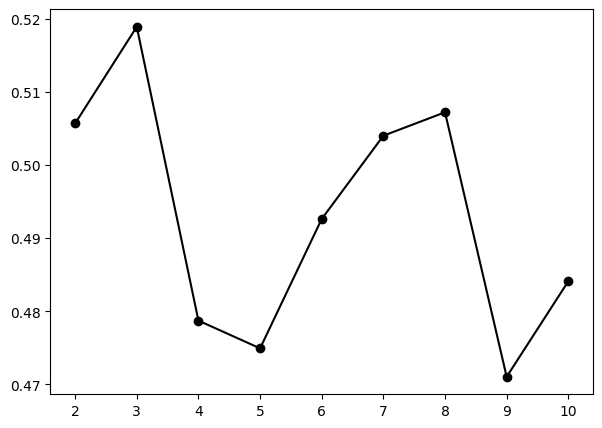

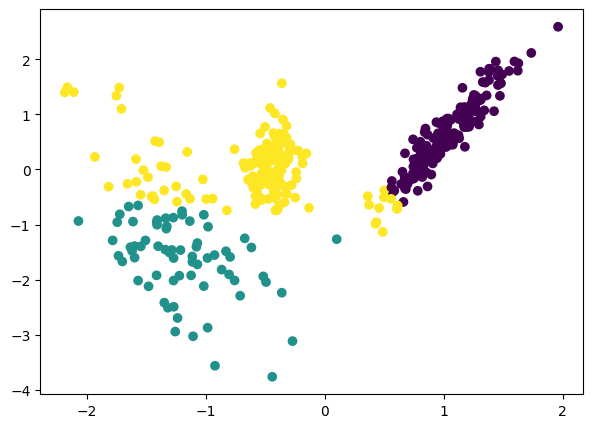

In [262]:
Ks = range(2,11)
scores = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42)
    y_c = km.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, y_c)
    scores.append(sil_score)
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(Ks, scores, 'o-k')

best_k = Ks[np.argmax(scores)]
km = KMeans(n_clusters=best_k, random_state=42)
y_c = km.fit_predict(X_scaled)
f = plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_c)

## 7. Fit the final K-means model

Fit the model using the optimal number of clusters defined above. Visualize the K-means results on two dimensions using different marker colors for each cluster.

## 8. Gaussian Mixture Models (GMM)

A Gaussian Mixture Model assumes that the data come from a mixture of several Gaussian distributions.

Compared with K-means, GMM can model clusters that are:

- elliptical
- overlapping
- different in size and orientation

## 9. Choosing the number of clusters/components for GMM: AIC/BIC

For Gaussian Mixture Models, a common selection criterion is the Akaike Information Criterion (AIC) or the Bayesian Information Criterion (BIC). Unlike inertia, AIC/BIC explicitly penalize overly complex models.

* Compute the AIC value for GMM with different number of components
* Select the optimal number of components
* Repeat the previous points using BIC


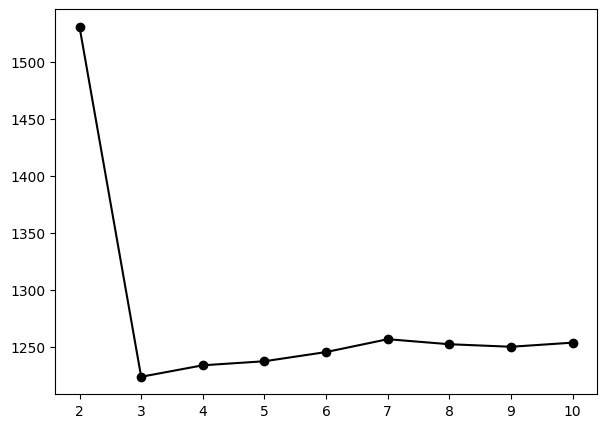

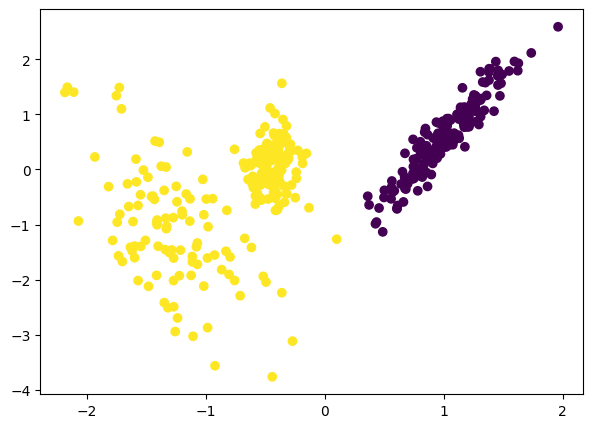

In [263]:
Ns_gauss = range(2,11)
scores = []

for n in Ns_gauss:
  gmm = GaussianMixture(n_components=n, covariance_type = "full", random_state=42)
  y_c = gmm.fit_predict(X_scaled)
  aic_score = gmm.aic(X_scaled)
  scores.append(aic_score)
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(Ns_gauss, scores, 'o-k')

best_n = Ns_gauss[np.argmax(scores)]
gmm = GaussianMixture(n_components=best_n, covariance_type = "full", random_state=42)
y_gmm_c = gmm.fit_predict(X_scaled)
f = plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_gmm_c)

## 10. Fit the final GMM model

Fit the final GMM model with the optimal number of clusters defined above. Visualize the results on two dimensions using a different marker color for each cluster.


## 11. Compare K-means and GMM
Compare the silhouette scores of the selected models respectivelly for K-means and GMM.

In [265]:
print(f"Optimal K for K-means (silhouette score): {best_k}")
km_final = KMeans(n_clusters=best_k, random_state=42)
y_c_kmeans = km_final.fit_predict(X_scaled)
silhouette_kmeans = silhouette_score(X_scaled, y_c_kmeans)
print(f"Silhouette Score for K-means with {best_k} clusters: {silhouette_kmeans:.4f}\n")

print(f"Optimal N for GMM (AIC): {best_n}")
gmm_final = GaussianMixture(n_components=best_n, random_state=42)
y_c_gmm = gmm_final.fit_predict(X_scaled)
silhouette_gmm = silhouette_score(X_scaled, y_c_gmm)
print(f"Silhouette Score for GMM with {best_n} components: {silhouette_gmm:.4f}")

Optimal K for K-means (silhouette score): 3
Silhouette Score for K-means with 3 clusters: 0.5189

Optimal N for GMM (AIC): 2
Silhouette Score for GMM with 2 components: 0.5068
